In [1]:
import pandas as pd

# File is already in left panel - load directly
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# Step 2: Data quality + Protect sensitive fields
print("Duplicates:", df.duplicated().sum())
print("Missing:", df.isnull().sum().sum())
print(df['Attrition'].value_counts())

# Protect PII
df_clean = df.drop(columns=['EmployeeNumber','EmployeeCount','Over18','StandardHours'])
df_clean['Attrition_Flag'] = df_clean['Attrition'].map({'Yes':1,'No':0})
df_clean['Tenure_Band'] = pd.cut(df_clean['YearsAtCompany'], bins=[-1,2,5,10,40], labels=['0-2 Early','3-5 Mid','6-10 Long','10+ Vet'])
print("Cleaned shape:", df_clean.shape)
df_clean.head()

Duplicates: 0
Missing: 0
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Cleaned shape: (1470, 33)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag,Tenure_Band
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,8,0,1,6,4,0,5,1,6-10 Long
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,1,10,3,3,10,7,1,7,0,6-10 Long
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,7,3,3,0,0,0,0,1,0-2 Early
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,0,8,3,3,8,7,3,0,0,6-10 Long
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,1,6,3,3,2,2,2,2,0,0-2 Early


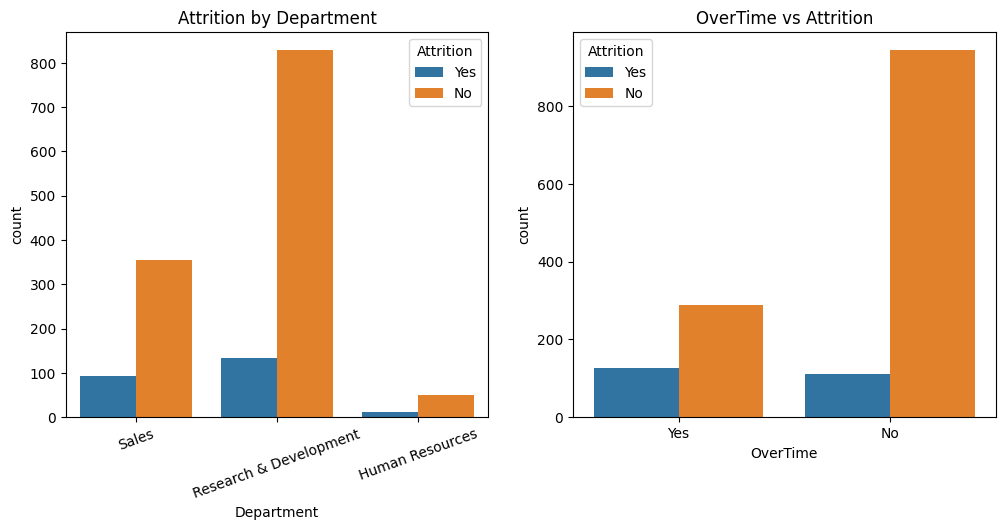

Early (0-2) Attrition: 102/342 = 29.8%
Tenure_Band
0-2 Early    29.824561
3-5 Mid      13.824885
6-10 Long    12.276786
10+ Vet       8.130081
Name: Attrition_Flag, dtype: float64


/tmp/ipykernel_1262/4164635214.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_clean.groupby('Tenure_Band')['Attrition_Flag'].mean()*100)


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Analyze by dept, tenure, role, compensation, workload
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(data=df_clean, x='Department', hue='Attrition')
plt.title('Attrition by Department')
plt.xticks(rotation=20)

plt.subplot(1,2,2)
sns.countplot(data=df_clean, x='OverTime', hue='Attrition')
plt.title('OverTime vs Attrition')
plt.show()

# Step 4: Derived - Early tenure rate
early_total = len(df_clean[df_clean['YearsAtCompany']<=2])
early_yes = len(df_clean[(df_clean['YearsAtCompany']<=2) & (df_clean['Attrition']=='Yes')])
print(f"Early (0-2) Attrition: {early_yes}/{early_total} = {early_yes/early_total*100:.1f}%")
print(df_clean.groupby('Tenure_Band')['Attrition_Flag'].mean()*100)

In [ ]:
# Save cleaned file for GitHub + Streamlit
df.to_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv', index=False)
df_clean.to_csv('attrition_cleaned.csv', index=False)

from google.colab import files
files.download('WA_Fn-UseC_-HR-Employee-Attrition.csv')
files.download('attrition_cleaned.csv')

print("Downloaded! Now go to GitHub")